Principios de Machine Learning - (PML)
Proyecto Tarea de Regresion - Modelos Polinomiales y Regularizados

Diego Burbano

## Importar las librerias necesarias para el modelo

In [146]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.plotting import scatterplotmatrix
from mlxtend.plotting import heatmap
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, StandardScaler, RobustScaler
from sklearn.pipeline import make_pipeline

import os
from google.colab import drive

from importlib.metadata import version


Revisión de versiones:

In [147]:
print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Scikit-learn: {version('scikit-learn')}")
print(f"Versión de Numpy: {version('numpy')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")
print(f"Versión de mlxtend: {version('mlxtend')}")
print(f"Versión de Google Colab: {version('google-colab')}")
print(f"Versión de Importlib: {version('importlib-metadata')}")
print(f"Versión de Seaborn: {version('seaborn')}")
print(f"Versión de Statsmodels: {version('statsmodels')}")

Versión de Pandas: 2.2.2
Versión de Scikit-learn: 1.6.1
Versión de Numpy: 1.26.4
Versión de Matplotlib: 3.10.0
Versión de mlxtend: 0.23.4
Versión de Google Colab: 1.0.0
Versión de Importlib: 8.6.1
Versión de Seaborn: 0.13.2
Versión de Statsmodels: 0.14.4


## 1. Carga de Datos


En esta sección se cargan al ambiente *Colabs* los datos alamcenados en la carpeta *Drive* de *Google Drive*

In [148]:
# En esta celda se esta montando el drive  que tiene almacenado los datos en la ruta MyDrive/datos.
drive.mount('/content/drive', force_remount=True)

# una vez se montó el drive, se cambia la ruta de archivo de 'content' de Colab por la ruta de Google Drive ('/MyDrive/datos/')
os.chdir('/content/drive/MyDrive/datos/')

Mounted at /content/drive


Se almacenan los datos en la variable *datos_sin _procesar*:

In [149]:
datos_sin_procesar = pd.read_csv('./Datos_Etapa-1.csv', sep=',')

Se revisan los  primeros datos del conjunto:

In [150]:
datos_sin_procesar.head()

,season,weekday,weathersit,temp,atemp,hum,windspeed,cnt,time_of_day
0,Winter,6,Clear,3.28,3.0014,0.81,0.0,16,Night
1,Winter,6,Clear,2.34,1.9982,0.80,0.0,40,Night
2,Winter,6,Clear,2.34,1.9982,0.80,0.0,32,Night
3,Winter,6,Clear,3.28,3.0014,0.75,0.0,13,Night
4,Winter,6,Clear,3.28,3.0014,0.75,0.0,1,Night


En total se cuentan con 9 variables, entre las cuales destacan tres de ellas que son categóricas: *season*, *weathersit* y *time_of_day*. Para efectos de tenerlas en cuenta en el modelo en la etapa de preparación se utilizarán técnicas para convertirlas en númericas y que así el modelo pueda procesarlas.

In [151]:
datos_sin_procesar.describe()

,weekday,temp,atemp,hum,windspeed,cnt
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,3.003683,15.358397,15.401157,0.627229,12.736540,189.463088
std,2.005771,9.050138,11.342114,0.192930,8.196795,181.387599
min,0.000000,-7.060000,-16.000000,0.000000,0.000000,1.000000
25%,1.000000,7.980000,5.997800,0.480000,7.001500,40.000000
50%,3.000000,15.500000,15.996800,0.630000,12.998000,142.000000
75%,5.000000,23.020000,24.999200,0.780000,16.997900,281.000000
max,6.000000,39.000000,50.000000,1.000000,56.996900,977.000000


Se cambian el nombre de las variables para facilidad en la preparación del  modelo:

In [152]:
columnas = ['ESTACION', 'DIA', 'CLIMA', 'TEMP', 'SENSACION', 'HUMEDAD', 'VELOCIDAD', 'CANTIDAD', 'JORNADA']
datos_sin_procesar.columns = columnas
datos_sin_procesar.head()

,ESTACION,DIA,CLIMA,TEMP,SENSACION,HUMEDAD,VELOCIDAD,CANTIDAD,JORNADA
0,Winter,6,Clear,3.28,3.0014,0.81,0.0,16,Night
1,Winter,6,Clear,2.34,1.9982,0.80,0.0,40,Night
2,Winter,6,Clear,2.34,1.9982,0.80,0.0,32,Night
3,Winter,6,Clear,3.28,3.0014,0.75,0.0,13,Night
4,Winter,6,Clear,3.28,3.0014,0.75,0.0,1,Night


## 2. Exploración de los datos, limpieza y preparación

A continuación, en una nueva variable (*datos*) se convierten las variables categóricas en númericas utilizando para ello *pd.get_dummies()* de la libreria *pandas* (*One-Hot Encoding*) debido a que estas variables son categoricas cardinales.

In [153]:
datos = pd.get_dummies(datos_sin_procesar, columns=["ESTACION", "CLIMA", "JORNADA"], dtype=np.uint8)

In [154]:
datos.head()

,DIA,TEMP,SENSACION,HUMEDAD,VELOCIDAD,CANTIDAD,ESTACION_Fall,ESTACION_Spring,ESTACION_Summer,ESTACION_Winter,CLIMA_Clear,CLIMA_Heavy Rain,CLIMA_Light Rain,CLIMA_Mist,JORNADA_Evening,JORNADA_Morning,JORNADA_Night
0,6,3.28,3.0014,0.81,0.0,16,0,0,0,1,1,0,0,0,0,0,1
1,6,2.34,1.9982,0.80,0.0,40,0,0,0,1,1,0,0,0,0,0,1
2,6,2.34,1.9982,0.80,0.0,32,0,0,0,1,1,0,0,0,0,0,1
3,6,3.28,3.0014,0.75,0.0,13,0,0,0,1,1,0,0,0,0,0,1
4,6,3.28,3.0014,0.75,0.0,1,0,0,0,1,1,0,0,0,0,0,1


Revisaremos si hay datos faltantes:

In [155]:
datos.isna().sum()

,0
DIA,0
TEMP,0
SENSACION,0
HUMEDAD,0
VELOCIDAD,0
CANTIDAD,0
ESTACION_Fall,0
ESTACION_Spring,0
ESTACION_Summer,0
ESTACION_Winter,0


No existen datos faltantes.

A continuación se verifican si existen instancias duplicadas, para su posterior eliminacion:

In [156]:
datos.duplicated().sum()

42

Existen 42 registros repetidos, los cuales eliminaremos:

In [157]:
datos = datos.drop_duplicates()

Verificamos que se hayan eliminado los registros:

In [158]:
datos.shape

(17337, 17)

En el set sin procesar contabamos con 17379, ahora contamos con 17337; la diferencia nos arroja los 42 registros repetidos.

### Análisis de variables

Se procede a analizar las variables del modelo antes de continuar con la división de los datos.

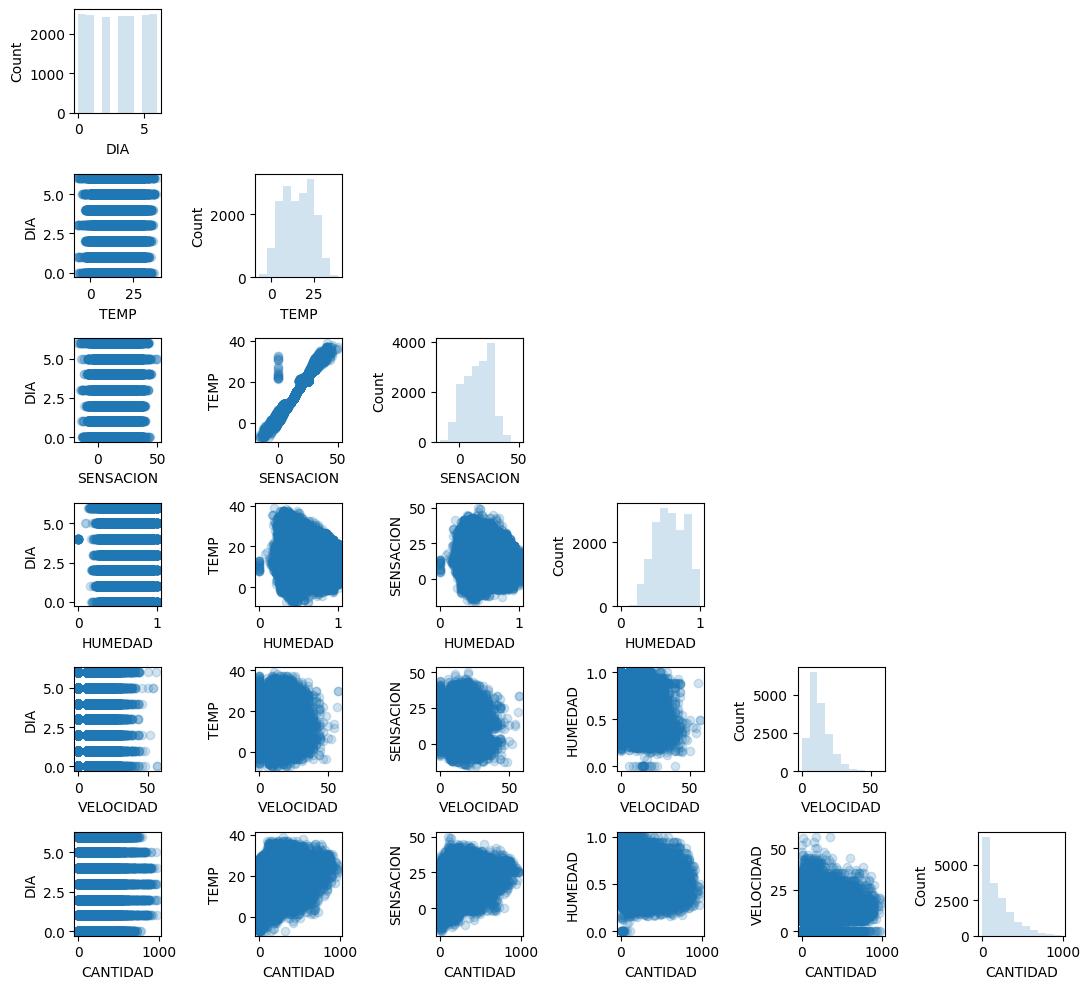

In [159]:
variables = ['DIA', 'TEMP', 'SENSACION', 'HUMEDAD', 'VELOCIDAD', 'CANTIDAD']
scatterplotmatrix(datos[variables].values, figsize=(11, 10), names = variables, alpha = 0.2)
plt.tight_layout()
plt.show()

Se presenta un mapa de calor para determinar la relación de las variables númericas:

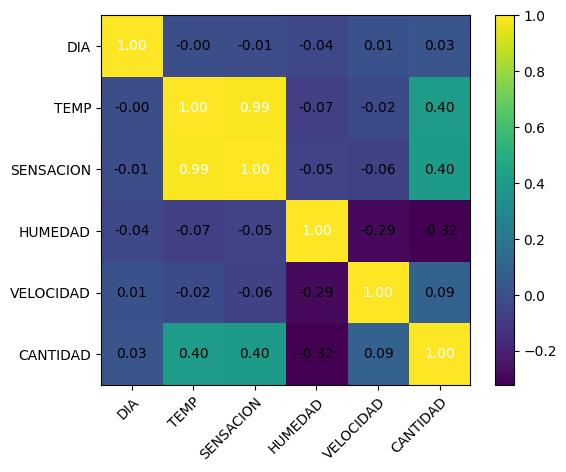

In [160]:
cm = np.corrcoef(datos[variables].values.T)
hm = heatmap(cm,row_names=variables, column_names=variables)
plt.show()

Debido a la baja correlación entre las variables *DIA* y *CANTIDAD*, y con el fin de determinar si se mantiene la variable *DIA* dentro de la construcción de los modelos, se realiza el analisis de como se comportan estas variables para determinar su posible incidencia en el modelo.

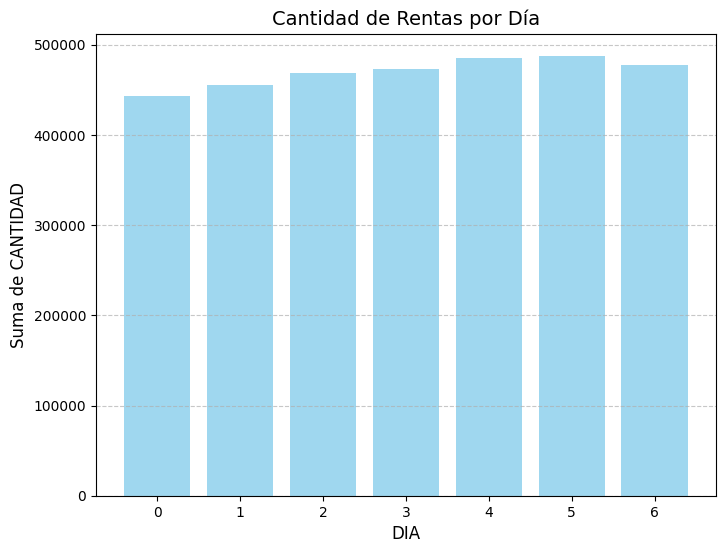

In [161]:
suma_cantidad_dia = datos.groupby('DIA')['CANTIDAD'].sum()
plt.figure(figsize=(8, 6))
plt.bar(suma_cantidad_dia.index, suma_cantidad_dia.values, color='skyblue', alpha=0.8)
plt.xlabel('DIA', fontsize=12)
plt.ylabel('Suma de CANTIDAD', fontsize=12)
plt.title('Cantidad de Rentas por Día', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(suma_cantidad_dia.index, fontsize=10)
plt.show()

La gráfica muestra una relación muy plana entre la cantidad de bicicletas rentadas frente al día de la semana. Esto en un principio parecería indicar que la incidencia de la variable *DIA* frente a *CANTIDAD* sería muy baja, confirmando el coeficiente de correlación mostrado previamente en el mapa de calor.

De la misma manera, se presenta el analisis de las variables categóricas una vez procesadas:

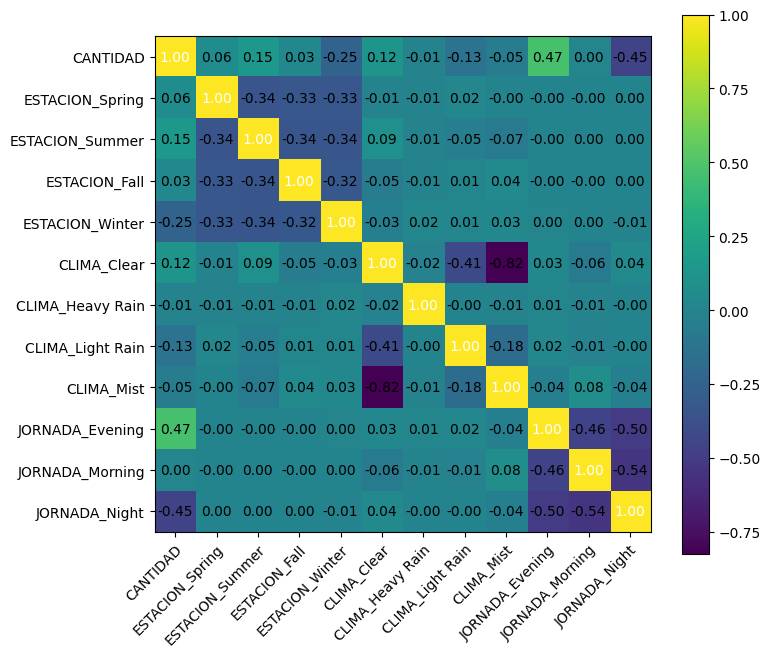

In [162]:
variables_categoricas_procesadas = ['CANTIDAD', 'ESTACION_Spring', 'ESTACION_Summer', 'ESTACION_Fall', 'ESTACION_Winter', 'CLIMA_Clear', 'CLIMA_Heavy Rain', 'CLIMA_Light Rain', 'CLIMA_Mist', 'JORNADA_Evening', 'JORNADA_Morning', 'JORNADA_Night' ]
cm = np.corrcoef(datos[variables_categoricas_procesadas].values.T)
hm = heatmap(cm, row_names=variables_categoricas_procesadas, column_names=variables_categoricas_procesadas, figsize=(8, 7))
plt.show()

De las gráficas anteriores, las cuales muestran la relación entre las variables podemos concluir:


1.   *DIA*: Presenta una correlación prácticamente nula con la variable *CANTIDAD* (0.03), lo anterior se confirma por la poca variabilidad que presenta, ya que la suma de los alquileres por día es casi uniforme, según el diagrama "Cantidad de Rentas por Día", razón por la cual se puede llegar a considerar eliminarla del analisis; no obstante lo anterior, no hay gran costo en incluirla en la construcción de los modelos y permitir que las técnicas determinen su relevancia, razón por la cual se decide mantenerla para la construcción de los modelos.
2.   *TEMP* y *SENSACION* tienen una correlación casi perfecta (0.99) lo cual se confirma con el grafico xy que compara estas variables (una linea recta); esto indica una multicolinealidad muy fuerte, lo cual puede llegar a ser un problema en el modelamiento. Considerando que la sensación térmica representa como el ser humano percipe la temperatura y teniendo en cuenta que la misma esta relacionada con factores como el viento y la humedad, su permanencia en el modelo no aportaría suficiente valor.
3.   *VELOCIDAD*: a pesar de su baja correlación con *CANTIDAD*, por las razones antes expuestas, se mantiene en el modelo ya que aportaría información relevante al modelo al haber eliminado la variable de sensación térmica (*SENSACION*).
4.   En relación con las variables categóricas que han sido procesadas, se decide mantenerlas dentro del análisis por las razones presentadas a continuación:
    a. A pesar de contar con variables que presentan baja correlación con la variable dependiente, éstas pueden tener un efecto indirecto a través de distintas interacciones.
    b. La relación existente entre variables independientes refuerza la idea que ciertas combinaciones o interacciones entre las variables podrían enriquecer el modelo.
    c. Al considerar usar un modelo polinómico, mantener variables con baja correlación directa puede ser relevante, ya que precisamente se consideran términos no lineales e interacciones entre variables.   







### Division de datos

Se separa la variable objetivo de las variables independientes y se elimina la variable *SENSACION* al mismo tiempo se separa la variable dependiente (*CANTIDAD*):

In [163]:
x = datos.drop(['CANTIDAD', 'SENSACION'], axis="columns")
y = datos['CANTIDAD']
x.head()

,DIA,TEMP,HUMEDAD,VELOCIDAD,ESTACION_Fall,ESTACION_Spring,ESTACION_Summer,ESTACION_Winter,CLIMA_Clear,CLIMA_Heavy Rain,CLIMA_Light Rain,CLIMA_Mist,JORNADA_Evening,JORNADA_Morning,JORNADA_Night
0,6,3.28,0.81,0.0,0,0,0,1,1,0,0,0,0,0,1
1,6,2.34,0.80,0.0,0,0,0,1,1,0,0,0,0,0,1
2,6,2.34,0.80,0.0,0,0,0,1,1,0,0,0,0,0,1
3,6,3.28,0.75,0.0,0,0,0,1,1,0,0,0,0,0,1
4,6,3.28,0.75,0.0,0,0,0,1,1,0,0,0,0,0,1


Se hace la definicion de conjuntos de entrenamiento y pruebas:

In [164]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=77)

Se verifica que el conjunto x_train no cuente con la variable objetivo (*CANTIDAD*)

In [165]:
x_train.head()

,DIA,TEMP,HUMEDAD,VELOCIDAD,ESTACION_Fall,ESTACION_Spring,ESTACION_Summer,ESTACION_Winter,CLIMA_Clear,CLIMA_Heavy Rain,CLIMA_Light Rain,CLIMA_Mist,JORNADA_Evening,JORNADA_Morning,JORNADA_Night
7697,2,9.86,0.94,15.0013,1,0,0,0,0,0,1,0,0,1,0
5830,1,23.96,0.74,11.0014,0,0,1,0,0,0,1,0,0,1,0
4589,5,20.20,0.73,12.9980,0,0,1,0,1,0,0,0,0,0,1
6726,3,17.38,0.94,7.0015,1,0,0,0,0,0,1,0,0,0,1
6150,0,17.38,0.68,6.0032,0,0,1,0,0,0,0,1,0,0,1


## 3. Construccion de modelo de regresion polinomial

**Busqueda de hiperparametros:**

Con el conjunto de datos preparado, entrenaremos el  modelo de regresión polinomial multivariable. Se define la variable *polynomial_regression*, la cual utilizaremos para la búsqueda de los hiperparámetros.

In [166]:
scaler = RobustScaler()
polynomial_regression = make_pipeline(
    PolynomialFeatures(),
    scaler,
    LinearRegression()
)

Utilizaremos un objeto de la clase *Kfold*, con el cual haremos una partición en 10 partes sobre el conjunto de entrenamiento que hemos definido previamente.
Así mismo, se define el espacio de búsqueda del hiperparámetro mediante la definición del diccionario *param_grid*. En esta variable almacenaremos los grados del polinomio, para nuestro caso 2 y 3, con los cuales entrenaremos el modelo en la búsqueda de los hiperparámetros.

In [167]:
kfold = KFold(n_splits=10, shuffle=True, random_state = 0)

In [168]:
param_grid = {'polynomialfeatures__degree': [2, 3]}

Finalmente, se procede con la búsqueda de hiperparámetros a traves de la creación de un objeto *GridSearchCV*; para ello utilizaremos las variables previamente definidas: *polynomial_regression*, *param_grid*, y *kfold*.

In [169]:
modelos_grid = GridSearchCV(polynomial_regression, param_grid, cv=kfold, n_jobs=-1)

Se realiza la búsqueda de hiperparámetros, utilizando para ello los conjuntos de entrenamiento compuesto por las variables *x_train* y *y_train*.

In [170]:
%%time
modelos_grid.fit(x_train, y_train)

CPU times: user 3.92 s, sys: 200 ms, total: 4.12 s
Wall time: 33 s


GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('polynomialfeatures',
                                        PolynomialFeatures()),
                                       ('robustscaler', RobustScaler()),
                                       ('linearregression',
                                        LinearRegression())]),
             n_jobs=-1, param_grid={'polynomialfeatures__degree': [2, 3]})

Consultamos el mejor hiperparámetro utilizando para ello el atributo *best_params_*.
Igualmente, se define el objeto *mejor_modelo* con el cual realizaremos las predicciones sobre el subconjunto de pruebas.

In [171]:
print("Mejor parámetro: ", modelos_grid.best_params_)

Mejor parámetro:  {'polynomialfeatures__degree': 3}


El mejor parámetro encontrado corresponde a un polinomio de grado 3.

In [172]:
mejor_modelo = modelos_grid.best_estimator_
mejor_modelo

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('robustscaler', RobustScaler()),
                ('linearregression', LinearRegression())])

Se realizan las predicciones, las cuales posteriormente se compararán con el subconjunto *y_train* y se presentan las métricas de rendimiento:

In [173]:
y_pred = mejor_modelo.predict(x_test)
rmse_poly = root_mean_squared_error(y_test, y_pred)
mae_poly = mean_absolute_error(y_test, y_pred)
r2_poly = r2_score(y_test, y_pred)

print(f'------ Mejor modelo de regresión polinomial ----')
print(f"RMSE: {rmse_poly:.2f}")
print(f"MAE: {mae_poly:.2f}")
print(f'R²: {r2_poly:.2f}')

------ Mejor modelo de regresión polinomial ----
RMSE: 132.36
MAE: 96.23
R²: 0.48


## 4. Construccion Modelo de Regresion Lasso

Se realiza la estandarización de los datos almacenando el nombre de las columnas en la variable *columns* y definiendo un objeto de la clase *RobustScaler()*.

In [174]:
columns = x_train.columns

In [175]:
scaler_lasso = RobustScaler()

In [176]:
x_train = scaler_lasso.fit_transform(x_train)
x_train = pd.DataFrame(x_train, columns=columns)

**Busqueda de hiperparametros y entrenamiento del modelo**

Para la búsqueda del mejor hiperparámetro alpha se utiliza un objeto de la clase *Kfold* con el cual se determinarán 10 subconjuntos a partir del conjunto de entrenamiento.
Seguidamente se define un objeto de la clase *Lasso* para realizar el entrenamiento con regresión regularizada.

In [177]:
kfold = KFold(n_splits=10, shuffle=True, random_state = 0)

In [178]:
lasso = Lasso()

Se define el espacio de búsqueda del hiperparámetro definiendo una variable *param_grid* a la cual se le asignarán los valores: 1, 2, 3, 4 y 5.

In [179]:
valores = [1, 2, 3, 4, 5]
param_grid = {'alpha': valores}

Se crea un objeto GridSearchCV utilizando las variables ya definidas: *lasso*, *param_grid* y *kfold*.
Adicionalmente se define la variable grid a la cual se le asigna la función para crear el objeto *GridSearchCV*.
Seguidamente se realiza la búsqueda de hiperparámetros utilizando el conjunto de entrenamiento.

In [180]:
grid = GridSearchCV(lasso, param_grid, cv=kfold, n_jobs=1)

In [181]:
grid.fit(x_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=Lasso(), n_jobs=1,
             param_grid={'alpha': [1, 2, 3, 4, 5]})

El mejor hiperparámetro se consulta utilizando el atributo *grid.best_params*.  Para nuestro caso de los valores definidos, el modelo encontró que el mejor de ellos es el 1.

In [182]:
print("Mejor parámetro: ", grid.best_params_)

Mejor parámetro:  {'alpha': 1}


Los coeficientes de la función se consultan con el atributo *coef_*.

In [183]:
mejor_modelo_lasso = grid.best_estimator_
list(zip(x_train.columns, mejor_modelo_lasso.coef_))

[('DIA', 4.122832089581362),
 ('TEMP', 99.83966449117672),
 ('HUMEDAD', -43.87193625491661),
 ('VELOCIDAD', -0.47053052251303634),
 ('ESTACION_Fall', 48.98693225778057),
 ('ESTACION_Spring', 16.145830168860556),
 ('ESTACION_Summer', -3.883244099205146),
 ('ESTACION_Winter', -5.983601958303451),
 ('CLIMA_Clear', 1.8960517446067564),
 ('CLIMA_Heavy Rain', 0.0),
 ('CLIMA_Light Rain', -28.950096418869443),
 ('CLIMA_Mist', -0.0),
 ('JORNADA_Evening', 84.73531538945791),
 ('JORNADA_Morning', -0.0),
 ('JORNADA_Night', -99.30866949468975)]

Se evalua el modelo utilizando el conjunto de pruebas previamente definido. Se realiza la estandarización de los datos del conjunto de pruebas.

In [184]:
x_test = scaler_lasso.transform(x_test)
x_test = pd.DataFrame(x_test, columns=columns)

In [185]:
y_pred = mejor_modelo_lasso.predict(x_test)
y_pred

array([ 82.57895377, 140.44400019, 248.15398642, ..., 244.94348803,
       258.06376658, 181.53442776])

In [186]:
rmse_lasso = root_mean_squared_error(y_test, y_pred)
mae_lasso = mean_absolute_error(y_test, y_pred)
r2_lasso = r2_score(y_test, y_pred)

print(f'------ Mejor modelo de regresión Lasso ----')
print(f"RMSE: {rmse_lasso:.2f}")
print(f"MAE: {mae_lasso:.2f}")
print(f'R²: {r2_lasso:.2f}')


------ Mejor modelo de regresión Lasso ----
RMSE: 139.89
MAE: 103.50
R²: 0.42


## 5. Evaluacion de Resultados

Para evaluar el mejor modelo se construye una tabla comparativa mostrando el rendimiento sobre el conjunto de prueba de los dos modelos seleccionados con las métricas RMSE, MAE y R cuadrado.

In [187]:
model_results = {
    'Modelo': ["Regresión Polinomial", "Regresion Regularizada Lasso"],
    'RMSE': [rmse_poly, rmse_lasso],
    'MAE': [mae_poly, mae_lasso],
    'R²': [r2_poly, r2_lasso]
}
pd.DataFrame(model_results)

,Modelo,RMSE,MAE,R²
0,Regresión Polinomial,132.359375,96.227436,0.478849
1,Regresion Regularizada Lasso,139.893185,103.499577,0.417833


Se concluye que el modelo que mejor generaliza el conjunto de pruebas es el modelo de regresión polinomial, ya que las metricas seleccionadas muestran que este modelo presenta un menor valor para la función de error.
Analizando particularmente el indicador RMSE, el valor arrojado por la regresión polinomial es un 5.7% menor al valor de la regresión regularizada Lasso (132.35 vs. 139.89).

## 6. Variables mas importantes

Con el fin de determinar las variables mas importantes para la predicción con base en el modelo de Lasso, se entrena un modelo de regresión Lasso con un valor alto de alpha, ya que la regularización anula los coeficientes de algunas variables, las cuales son las menos importantes, anulando su influencia sobre las predicciones. De tal manera que sobresalen las variables que mayor influencia tienen en el modelo.

In [188]:
lasso_sv = Lasso(alpha=10)
lasso_sv.fit(x_train, y_train)
pd.DataFrame(zip(x_train.columns, lasso_sv.coef_),columns=["Variable","Coeficiente"])

,Variable,Coeficiente
0,DIA,0.000000
1,TEMP,75.963889
2,HUMEDAD,-32.823247
3,VELOCIDAD,0.000000
4,ESTACION_Fall,0.000000
5,ESTACION_Spring,0.000000
6,ESTACION_Summer,-0.000000
7,ESTACION_Winter,-0.000000
8,CLIMA_Clear,0.000000
9,CLIMA_Heavy Rain,-0.000000


De acuerdo con los resultados de este último modelo, las variables mas importantes son:


*   TEMP - temp: Temperatura
*   HUMEDAD - hum: Humedad
*   JORNADA_Evening - time_of_day / Evening: Hora del dia - En horas de la tarde
*   JORNADA_Night - time_of_day / Night: Hora del dia - En horas de la noche



## **Análisis de Resultados**

1. *¿Cuál es el grado de la transformación polinomial que fue seleccionado utilizando la técnica de validación?*

     Utilizando la técnica de validación cruzada sobre el conjunto de entrenamiento, el grado de transformación polinomial seleccionado fue 3, es decir un polinomio de 3 grado.

2. *¿Cuál fue el valor de α que fue seleccionado utilizando la técnica de validación para la regresión Lasso?*
     
     El valor de alfa seleccionado como mejor hiperparámetro fue 1.


3. *A partir de la tabla comparativa, ¿cuál modelo ofrece el mejor rendimiento sobre el conjunto test? ¿Qué interpretación puedes darles a los valores obtenidos sobre las métricas de rendimiento?*

    Se concluye que el modelo que mejor generaliza el conjunto de pruebas es el modelo de regresión polinomial, ya que las metricas seleccionadas muestran que este modelo presenta un menor valor para la función de error.

    Analizando particularmente el indicador RMSE, el valor arrojado por la regresión polinomial es un 5.7% menor al valor de la regresión regularizada Lasso (132.35 vs. 139.89).

4. *¿Cuáles variables fueron seleccionadas con el modelo Lasso? A partir de estas, ¿qué interpretación de cara al problema puedes dar? Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema.*

    En el apartado 6 del presente Notebook - *Variables mas importantes*, se presenta como anular las variables menos representativas a traves del entrenamiento de un modelo de Lasso con un alpha elevado, logrando así anular su efecto sobre las predicciones de la variable objetivo.

    Como resultado, se encontraron las siguientes variables mas importantes:

    *   TEMP - temp: Temperatura
    *   HUMEDAD - hum: Humedad
    *   JORNADA_Evening - time_of_day / Evening: Hora del dia - En horas de la tarde
    *   JORNADA_Night - time_of_day / Night: Hora del dia - En horas de la noche

    Tomando en cuenta estas variables, y de cara a mejorar el servicio y conocer los factores que inciden en su eficiencia, se pueden proponer algunas decisiones:

    1. Ajuste de la oferta según la Temperatura, ya que en días calidos se debe garantizar una mayor disponibilidad de bicicletas, previendo una mayor demanda.
    2. Para días húmedos, se pueden establecer medidas tales como descuentos o promociones para aumentar su demanda, debido a la correlación negativa de la variable humedad con relación a la cantidad de bicicletas rentadas.
    3. Optimización de la operación en horas de la tarde, debido al aumento de la cantidad de bicicletas rentadas en esta franja. Se debe garantizar la disponibilidad de bicicletas para garantizar la prestación correcta del servicio.
    4. Reducción de costos operativos en horas de la noche, ya que la demanda es menor. De esta manera se pueden ajustar la cantidad de bicicletas disponibles para la renta, y aprovechar esta franja horaria para realizar labores de mantenimiento preventivo sobre las restantes, asegurando una mejor calidad del servicio.
   